[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/EelcoHoogendoorn/numga/blob/rewrite/rewrite/examples/quadrics/elliptic_physics/s2_physics.ipynb) [![Open in GitHub Codespaces](https://github.com/codespaces/badge.svg)](https://codespaces.new/EelcoHoogendoorn/numga?ref=rewrite)

# Rigid bodies on the sphere

Ellipses on the 2-sphere that spin and collide. The rigid motions of the sphere are the rotations of space, so a body is placed by a rotor, and its shape is a quadric: a quadratic form whose negative points are the inside. Everything below is written in the algebra of three-dimensional space.

In [1]:
# Setup environment: clone repository and install dependencies if running in Colab
import sys
from pathlib import Path

if "google.colab" in sys.modules:
    import os, shutil, subprocess
    os.chdir("/content")  # Always reset to /content
    repo_dir = Path("/content/numga_repo")
    if not repo_dir.exists():
        subprocess.run(["git", "clone", "--depth", "1", "-b", "rewrite", "https://github.com/EelcoHoogendoorn/numga.git", str(repo_dir)], check=True)
    else:
        subprocess.run(["git", "-C", str(repo_dir), "pull", "origin", "rewrite"], check=False)
        for mod in list(sys.modules.keys()):
            if mod.startswith("examples") or mod.startswith("numga"):
                del sys.modules[mod]
    rewrite_dir = repo_dir / "rewrite"
    src_dir = rewrite_dir / "src"
    for p in [str(src_dir), str(rewrite_dir)]:
        if p not in sys.path:
            sys.path.insert(0, p)

# Ensure rewrite root is in sys.path when running locally:
for cand in [Path.cwd(), *Path.cwd().parents]:
    if (cand / "examples" / "quadrics" / "elliptic_physics").is_dir():
        if str(cand) not in sys.path:
            sys.path.insert(0, str(cand))
        if str(cand / "src") not in sys.path:
            sys.path.insert(0, str(cand / "src"))
        break
    if (cand / "rewrite" / "examples" / "quadrics" / "elliptic_physics").is_dir():
        p = str(cand / "rewrite")
        if p not in sys.path:
            sys.path.insert(0, p)
        if str(cand / "rewrite" / "src") not in sys.path:
            sys.path.insert(0, str(cand / "rewrite" / "src"))
        break

In [2]:
%matplotlib inline
from dataclasses import replace

import numpy as np
from IPython.display import Image, display
from PIL.Image import fromarray

from numga.algebras import Spherical3D
from examples import instantiate
from examples.animation import save_animation
from examples.quadrics.elliptic_physics import render, scenarios

np.set_printoptions(precision=4, suppress=True)

ga = Spherical3D                                   # Cl(3): the points of the sphere are the directions of space
core = instantiate("examples.quadrics.elliptic_physics.core", ga)   # the physics engine, for this sphere
mv = core.mv

Point = ga.gatype.antivector()                     # a point of the sphere
Plane = ga.gatype.vector()                         # a great circle
Motor = ga.gatype.rotor()                          # a rigid motion of the sphere: a rotation of space
Quadric = ga.gatype((Plane, Point))                # primal: a point's polar plane
DualQuadric = ga.gatype((Point, Plane))            # dual: a plane's pole

basis = mv.antivector(np.eye(3)).normalized()      # the points on the x, y and z axes

A body's shape is an ellipse: a dual quadric that sums the axis points, each paired with itself, weighted by tan² of the half-widths and −1 at the pole. Its inverse is the primal form, negative inside. Rendering is implicit: a pixel of the front hemisphere is a point of the sphere, and it is inside where the form is negative.

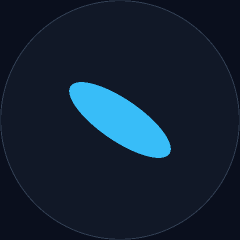

In [3]:
half_widths = np.radians([30.0, 10.0])
ellipse: DualQuadric = (basis * (basis & Plane) * np.array([*np.tan(half_widths) ** 2, -1.0])).sum(axis=0)
placement: Motor = (mv.xy * 0.3).exp()                                  # turned in the view, centred on it
form: Quadric = placement >> ellipse.inverse()(placement << Point)        # p ∨ form(p) < 0 inside

coordinates, disk, rim = render.hemisphere(480)                        # the front hemisphere's pixels, as (x, y, z)
pixels: Point = mv.yz * coordinates[:, 0] + mv.zx * coordinates[:, 1] + mv.xy * coordinates[:, 2]
inside = (pixels & form(pixels)) < 0.0                                 # one evaluation of the form per pixel

display(fromarray(render.paint(inside[None], render.rgb(["#38bdf8"]), disk, rim, 2)))

Two bodies are apart when some blend A + λB, λ > 0, of their forms is positive definite. The least eigenvalue of the best blend is therefore a margin, negative when they collide, and its eigenvector is the deepest point. The contact wrench is pushed through each body's inverse inertia, and the elastic impulse reverses the rate at which the bodies close.

margin: [-0.0154]
closing rate before and after: [-0.0593] [0.0593]


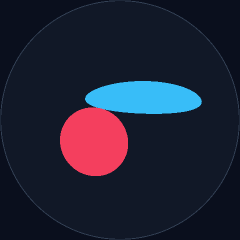

In [4]:
# Two ellipses spinning toward each other. scenarios.ellipses fills each with mass points and forms its
# inertia, the map from a rate to its momentum: Σ m p ∨ (p × rate), each point joined with its own motion.
bodies = scenarios.ellipses(
    half_angles=np.array([[30.0, 8.0], [17.0, 17.0]]), mass=np.array([1.0, 1.2]),
    # 0.3 rad either side of the view's centre; the scenarios fold in a camera turn, which this undoes.
    placement=scenarios.CAMERA.inverse() * scenarios.toward(np.array([0.3, 0.3]), np.array([0.7 + np.pi, 0.7])),
    rate=np.array([[-0.5, -2.0, 0.3], [1.0, 2.0, 0.2]]), colors=["#38bdf8", "#f43f5e"], n_phi=96,
)
a, b = np.array([0]), np.array([1])

# Detection, in the first body's frame: the margin of the best blend, and the deepest point.
relative: Motor = bodies.motor[a].inverse() * bodies.motor[b]
margin, deepest = core.overlap(bodies.C[a], relative >> bodies.C[b](relative << Point))
contact_plane: Plane = bodies.C[a](deepest).normalized()              # the first body's polar plane at the deepest point
contact: Point = bodies.Q[a](contact_plane)                            # its pole: the contact point
one = contact_plane | contact                                          # the contact wrench in a's frame
other = relative << one                                                # and in b's

# Handling: the rate at which the bodies close along the wrench, and the impulse that reverses it.
response_one, response_other = bodies.I_inv[a](one), bodies.I_inv[b](other)   # each body's rate per unit push
closing = response_one.regressive(bodies.momentum[a]) - response_other.regressive(bodies.momentum[b])
compliance = one.regressive(response_one) + other.regressive(response_other)
impulse = -2.0 * closing / compliance
momentum_a, momentum_b = bodies.momentum[a] + one * impulse, bodies.momentum[b] - other * impulse
closing_after = response_one.regressive(momentum_a) - response_other.regressive(momentum_b)

print("margin:", margin.to_array())
print("closing rate before and after:", closing.to_array(), closing_after.to_array())

inside = (pixels & bodies.world()[:, None](pixels)) < 0.0                 # [2, pixels] the same test, per body

display(fromarray(render.paint(inside, bodies.color, disk, rim, 2)))

The engine does this every substep for every pair within reach, after moving each body by a midpoint step along its rate. Seven ellipses, needles to discs:

Saved /Users/eelco/development/hobby/numga/rewrite/plots/spherical_quadric_physics_17.gif


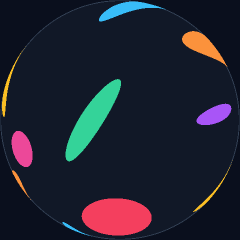

In [5]:
# Seven ellipses, needles to discs: half-widths in degrees, masses, where each starts, and body-frame rates.
bodies = scenarios.ellipses(
    half_angles=np.array([[30.0, 6.0], [17.0, 17.0], [28.0, 6.5], [24.0, 5.5], [15.0, 4.0], [26.0, 9.0], [9.0, 9.0]]),
    mass=np.array([1.0, 1.2, 0.9, 0.8, 0.5, 1.1, 0.4]),
    placement=scenarios.toward(np.array([0.35, 1.05, 1.15, 1.10, 1.25, 0.90, 1.55]), np.array([0.2, 0.7, 2.1, 3.6, 4.9, -0.67, 2.90])),
    rate=np.array([[0.8, 2.6, 0.5], [1.8, -1.2, 0.6], [-1.7, 1.5, -0.6], [2.0, 1.0, -0.5],
                   [-2.2, -1.8, 0.7], [1.6, 1.4, 0.7], [-2.4, 0.8, -0.4]]),
    colors=["#38bdf8", "#f43f5e", "#fbbf24", "#34d399", "#a855f7", "#fb923c", "#ec4899"],
    n_phi=384,
)
def step(bodies, dt: float):
    """A midpoint step of every body along its rate; the momentum stays in the body frame."""
    motor, momentum = bodies.motor, bodies.momentum
    half = (motor * (bodies.I_inv(momentum) * (dt / 4)).exp()).normalized()   # half a step ahead
    rate = bodies.I_inv((motor.inverse() * half) << momentum)                 # the rate at the midpoint
    moved = (motor * (rate * (dt / 2)).exp()).normalized()
    return replace(bodies, motor=moved, momentum=(motor.inverse() * moved) << momentum)


def collide(bodies, dt: float):
    """Elastic impulses for every pair that overlaps and is moving deeper in."""
    i, j = np.triu_indices(len(bodies.color), 1)                              # every pair once

    def margins(motors: Motor):
        relative = motors[i].inverse() * motors[j]
        return *core.overlap(bodies.C[i], relative >> bodies.C[j](relative << Point)), relative

    margin, deepest, relative = margins(bodies.motor)
    ahead = (bodies.motor * (bodies.rate() * (dt / 2)).exp()).normalized()    # every body a little further along
    touching = (margin < 0.0) & (margins(ahead)[0] < margin)                  # overlapping, and getting deeper
    contact_plane = bodies.C[i](deepest).normalized()
    wrench_one = contact_plane | bodies.Q[i](contact_plane)
    wrench_other = relative << wrench_one
    momentum = bodies.momentum
    for a, b, one, other in zip(i[touching], j[touching], wrench_one[touching], wrench_other[touching]):
        response_one, response_other = bodies.I_inv[a](one), bodies.I_inv[b](other)
        closing = response_one.regressive(momentum[a]) - response_other.regressive(momentum[b])
        impulse = -2.0 * closing / (one.regressive(response_one) + other.regressive(response_other))
        momentum = momentum.at[a].set(momentum[a] + one * impulse).at[b].set(momentum[b] - other * impulse)
    return replace(bodies, momentum=momentum)


def simulate(bodies, frames: int, dt: float):
    """Each frame's state, as it is asked for: six substeps of motion and contact between frames."""
    for frame in range(frames):
        yield bodies
        for substep in range(6):
            bodies = collide(step(bodies, dt / 6), dt / 6)


# Each frame, the implicit test per pixel and body, computed as the animation is written:
coverage = ((pixels & state.world()[:, None](pixels)) < 0.0 for state in simulate(bodies, 160, 0.015))
frames = (render.paint(inside, bodies.color, disk, rim, 2) for inside in coverage)

display(Image(filename=save_animation(frames, "spherical_quadric_physics", 15)))

In [6]:
# checks
assert margin.to_array()[0] < 0.0                                      # the two ellipses meet
np.testing.assert_allclose(closing_after.to_array(), -closing.to_array(), rtol=1e-12)   # the closing rate reverses
states = list(simulate(bodies, 40, 0.015))                             # a shorter run of the same crowd
energy = np.array([state.kinetic_energy().to_array() for state in states])
momentum = np.array([state.total_momentum().norm().to_array() for state in states])
assert np.ptp(energy) / energy[0] < 1e-3                               # the crowd keeps its energy
assert np.ptp(momentum) / momentum[0] < 1e-12                          # and its total momentum